# Experiment: Number of Frames from extracted Video for Vton Pipeline

## Thoughts / Hypothesis

In this paper, we investigate how many frames of a panoramic video (evenly distributed over 360°)
are necessary to obtain a stable camera parameter estimate via VGGT (COLMAP-compatible output)
and, based on this, a clean 3D reconstruction with gsplat.

**Hypothesis (a-priori):**
- As the number of frames increases, the geometric coverage (baseline/viewpoint density) increases and, with it,
  typically the robustness of the pose estimation, which should result in better VGGT metrics (lower MSE, higher PSNR).
  At the same time, we expect **diminishing marginal utility**: Above a certain number of frames, the additional
  viewpoints are too similar (too small baselines), so that measurement noise, tracking errors, or local minima
- At the same time, we expect **decreasing marginal utility**: Above a certain number of frames, the additional
  viewpoints are too similar (too small baselines), so that measurement noise, tracking errors, or local minima in the
  optimization are no longer systematically reduced. However, computing time and pipeline costs continue to increase.
- In addition, it is possible that individual angle ranges (e.g., strong self-occlusion, specular highlights,
  little texture, fast movements) remain problem areas regardless of n_frames – visible as
  **angle-dependent peaks** in the MSE or drops in the PSNR.

The aim of the experiment is therefore to determine a frame count that:
(1) provides robust, consistent camera estimation,
(2) enables high-quality reconstruction,
(3) remains within a reasonable runtime/cost budget.



**Important for scientific interpretation:**
- We currently only have 2 people. Differences between individuals can arise due to texture, clothing,
  lighting, self-occlusion, pose/movement → generalizability is limited.
- Therefore, we consider:
  (a) Person 1 separately,
  (b) Person 2 separately,
  (c) combined evaluation per frame count.


## Number of used Frames

Because we have 360 degrees videos, the angle between the frames are getting smaller with more frames used. Therefore, the first steps are smaller between frames and getting larger with more frames used.
 
- [12, 16, 20, 24, 30, 40, 60]

## Evaluation

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

# wandb.login()

api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\flori\.netrc.


In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

def infer_n_frames(label, run=None):
    """
    Versucht n_frames zu finden:
    1) aus label:   can_12 -> 12
    2) aus run.id / run.name: ...nf12...
    3) aus run.config (falls vorhanden)
    """
    m = re.search(r"_(\d+)$", label)
    if m:
        return int(m.group(1))

    if run is not None:
        for s in [getattr(run, "id", ""), getattr(run, "name", "")]:
            m = re.search(r"nf(\d+)", str(s))
            if m:
                return int(m.group(1))

        # optional: config keys (nur falls du so etwas loggst)
        cfg = getattr(run, "config", {}) or {}
        for k in ["n_frames", "num_frames", "frames", "nf"]:
            if k in cfg and isinstance(cfg[k], (int, float)):
                return int(cfg[k])

    raise ValueError(f"Konnte n_frames nicht bestimmen für label={label} (und run={getattr(run,'id',None)})")


def add_angle_column(df, n_frames, xkey="_step", angle_key="angle_deg", include_360_endpoint=False):
    """
    Mappt step -> Grad.
    - Standard (include_360_endpoint=False): 360/n_frames pro Frame (z.B. 12 -> 0..330)
      (typisch ohne doppeltes 360°=0° Bild)
    - Wenn include_360_endpoint=True: 360/(n_frames-1) (z.B. 12 -> 0..360)
    """
    denom = (n_frames - 1) if include_360_endpoint else n_frames
    denom = max(1, denom)
    df = df.copy()
    df[angle_key] = df[xkey].astype(float) * (360.0 / denom)
    return df


In [14]:
def load_metric(run_path, metric, xkey="_step", samples=20000):
    """
    Lädt (xkey, metric) aus einem Run als DataFrame.
    scan_history ist für große Runs zuverlässiger als history().
    """
    run = api.run(run_path)
    rows = []
    for row in run.scan_history(keys=[xkey, metric], page_size=1000):
        if row.get(metric) is None or row.get(xkey) is None:
            continue
        rows.append({xkey: row[xkey], metric: row[metric]})
        if len(rows) >= samples:
            break
    df = pd.DataFrame(rows).drop_duplicates(subset=[xkey]).sort_values(xkey)
    return df, run


def plot_two_metrics_with_x_360(labels, run_paths, metrics, xkey="_step", smoothing_window=10, include_360_endpoint=False):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for ax, metric in zip(axes, metrics):
        for label in labels:
            df, run = load_metric(run_paths[label], metric, xkey=xkey)

            n_frames = infer_n_frames(label, run)
            df = add_angle_column(df, n_frames, xkey=xkey, include_360_endpoint=include_360_endpoint)

            y = df[metric].rolling(window=smoothing_window, min_periods=1).mean()
            ax.plot(df["angle_deg"], y, label=label)

        ax.set_title(metric)
        ax.set_xlabel("Angle (deg)")
        ax.set_ylabel(metric)
        ax.set_xlim(0, 360)
        ax.set_xticks(np.arange(0, 361, 60))
        ax.grid(True, alpha=0.3)

    # eine gemeinsame Legende (statt doppelt)
    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_legend, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.suptitle(f"{entity}/{project} — Vergleich", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_two_metrics(labels, run_paths, metrics, xkey, smooth_window=10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for ax, metric in zip(axes, metrics):
        for label in labels:
            df, run = load_metric(run_paths[label], metric, xkey=xkey)

            y = df[metric].rolling(window=smooth_window, min_periods=1).mean()
            ax.plot(df[xkey], y, label=label)
        ax.set_title(metric)
        ax.set_xlabel(xkey)
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
    # eine gemeinsame Legende (statt doppelt)
    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_legend, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.suptitle(f"{entity}/{project} — Vergleich", y=1.02)
    plt.tight_layout()
    plt.show()
            
def metric_stats_for_label(label, metric, xkey="_step"):
    df, run = load_metric(run_paths[label], metric, xkey=xkey)
    n_frames = infer_n_frames(label, run)

    # Keine Glättung für Statistik (Glättung nur für Visualisierung)
    vals = df[metric].astype(float).values

    return {
        "label": label,
        "n_frames": n_frames,
        "person": "can" if "can_" in label else "florian",
        "metric": metric,
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "std": float(np.std(vals)),
        "p05": float(np.quantile(vals, 0.05)),
        "p95": float(np.quantile(vals, 0.95)),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "n_points": int(len(vals)),
    }

import numpy as np
import matplotlib.pyplot as plt

def plot_mean_median_std_over_frames(stats_df, metrics=None, title_prefix="", clamp_lower=True):
    """
    Plottet pro Metrik:
      - mean (Linie)
      - median (Linie)
      - mean ± std (Band)
    gegen n_frames.

    Erwartete Spalten in stats_df:
      ['metric','n_frames','mean','median','std'] (weitere Spalten ok)

    clamp_lower:
      - wenn True, wird das untere Band bei 0 gekappt (sinnvoll für MSE)
    """
    df = stats_df.copy()
    df["n_frames"] = df["n_frames"].astype(int)

    if metrics is None:
        metrics = sorted(df["metric"].unique().tolist())

    for metric in metrics:
        d = df[df["metric"] == metric].sort_values("n_frames")

        # Falls du doch mehrere Runs pro n_frames hast: hier robust mitteln
        d = (d.groupby("n_frames", as_index=False)
               .agg(mean=("mean","mean"),
                    median=("median","mean"),
                    std=("std","mean")))

        x = d["n_frames"].to_numpy()
        mean = d["mean"].to_numpy()
        median = d["median"].to_numpy()
        std = d["std"].to_numpy()

        lower = mean - std
        upper = mean + std
        if clamp_lower:
            lower = np.maximum(lower, 0.0)

        plt.figure(figsize=(8, 5))
        plt.plot(x, mean, label="mean")
        plt.plot(x, median, label="median")
        plt.fill_between(x, lower, upper, alpha=0.2, label="mean ± std")

        plt.title(f"{title_prefix}{metric}: mean/median/std vs n_frames")
        plt.xlabel("n_frames")
        plt.ylabel(metric)
        plt.xticks(x)  # zeigt genau deine getesteten Framezahlen
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [31]:
entity = "vton_pipeline"
project = "vton_pipeline_frames"

run_ids = {
    "florian_12": "slurm-2982123-nf12",
    "florian_16": "slurm-2982123-nf16",
    "florian_20": "slurm-2982123-nf20",
    "florian_24": "slurm-2982123-nf24",
    "florian_30": "slurm-2982123-nf30",
    "florian_40": "slurm-2982123-nf40",
    "florian_60": "slurm-2982123-nf60",
    "can_12": "slurm-3279493-nf12",
    "can_16": "slurm-3279493-nf16",
    "can_20": "slurm-3279493-nf20",
    "can_24": "slurm-3279493-nf24",
    "can_30": "slurm-3279493-nf30",
    "can_40": "slurm-3279493-nf40",
    "can_60": "slurm-3279493-nf60"
}

run_paths = {k: f"{entity}/{project}/{rid}" for k, rid in run_ids.items()}

can_labels = [k for k in run_ids.keys() if k.startswith("can_")]
florian_labels = [k for k in run_ids.keys() if k.startswith("florian_")]
all_labels = can_labels + florian_labels

### VGGT

In [5]:
metrics = ["vggt/mse", "vggt/psnr"]
xkey   = "_step"

#### Can

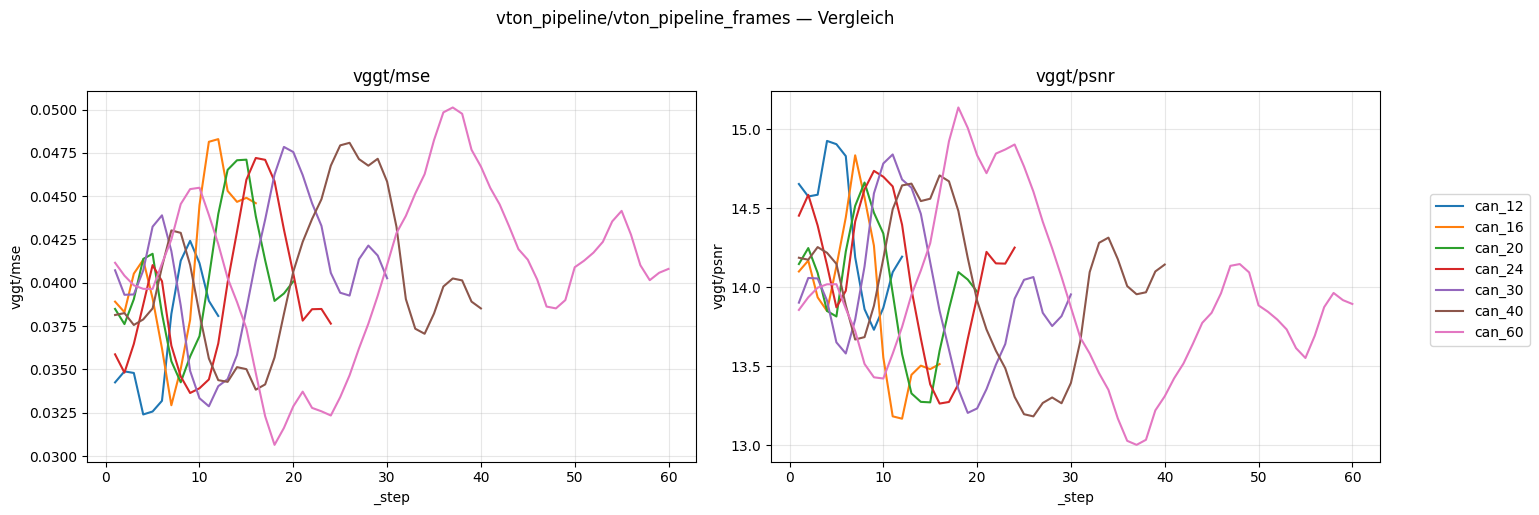

In [7]:
plot_two_metrics(
    labels=can_labels,
    run_paths=run_paths,
    metrics=metrics,
    xkey="_step",
    smooth_window=3
)

The “_step” plot is primarily a sanity check. It shows that the curve lengths are correct. However, it is difficult to detect angle-dependent artifacts here because the x-axis is distorted by the different step sizes. Therefore, we will now look at the metrics over the angle. Please note: these are not entirely comparable, as the step size varies and the recorded video does not cover exactly 360°.


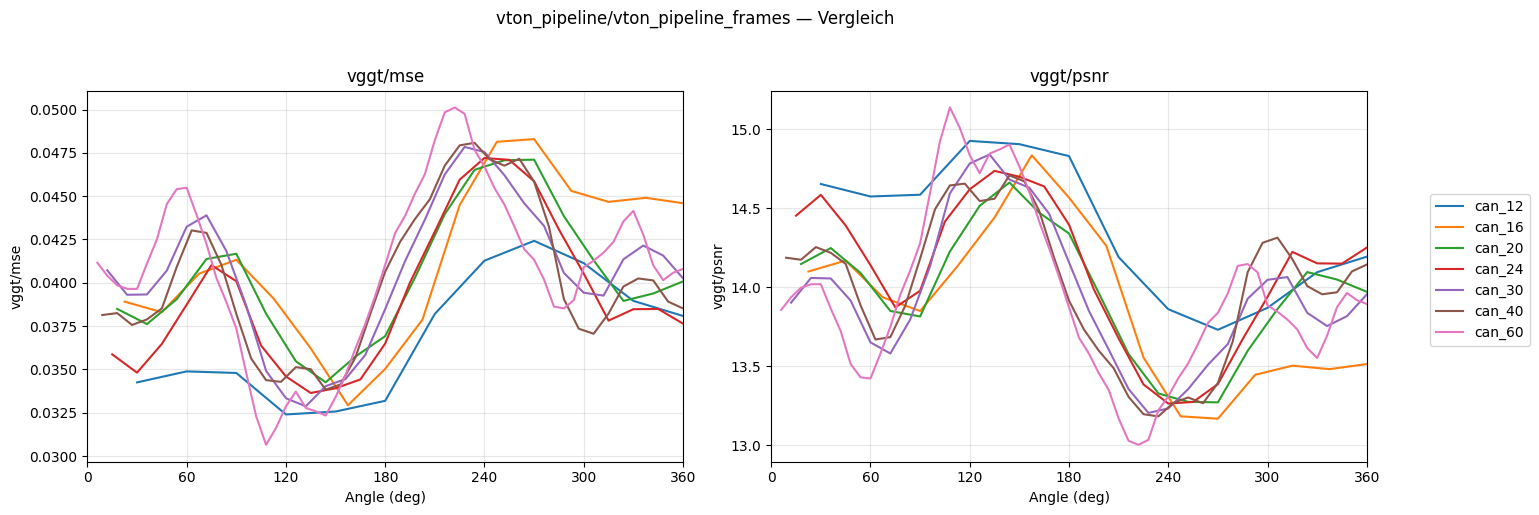

In [6]:
plot_two_metrics_with_x_360(
    labels=can_labels,
    run_paths=run_paths,
    metrics=metrics,
    xkey="_step",
    smoothing_window=3,          #winkel-spezifische Artefakte sichtbar halten
    include_360_endpoint=False
)

The dominant errors look viewpoint-driven (angle-dependent difficulty) and not primarily caused by “too few frames.” 

In [12]:
rows_c = []
for label in can_labels:
    for metric in metrics:
        rows_c.append(metric_stats_for_label(label, metric))

stats_can_df = pd.DataFrame(rows_c).sort_values(["metric", "n_frames"])
stats_can_df

,label,person,n_frames,metric,mean,median,std,p05,p95,min,max,n_points
0,can_12,can,12,vggt/mse,0.037124,0.036877,0.004305,0.031020,0.043528,0.027069,0.045251,12
2,can_16,can,16,vggt/mse,0.041554,0.041895,0.005594,0.031357,0.049035,0.031002,0.051328,16
4,can_20,can,20,vggt/mse,0.040464,0.040011,0.004506,0.033865,0.047191,0.031555,0.048428,20
6,can_24,can,24,vggt/mse,0.039247,0.038002,0.004715,0.032549,0.046508,0.031517,0.049348,24
8,can_30,can,30,vggt/mse,0.040533,0.040737,0.004470,0.033704,0.047243,0.030037,0.049263,30
10,can_40,can,40,vggt/mse,0.040170,0.039017,0.004494,0.033712,0.047955,0.032106,0.049377,40
12,can_60,can,60,vggt/mse,0.040680,0.040874,0.004940,0.031467,0.048663,0.029455,0.051590,60
1,can_12,can,12,vggt/psnr,14.334411,14.332769,0.526997,13.615130,15.113073,13.443686,15.675291,12
3,can_16,can,16,vggt/psnr,13.855372,13.778601,0.608595,13.096509,15.036800,12.896496,15.086064,16
5,can_20,can,20,vggt/psnr,13.956363,13.978220,0.486120,13.261527,14.703078,13.149024,15.009311,20


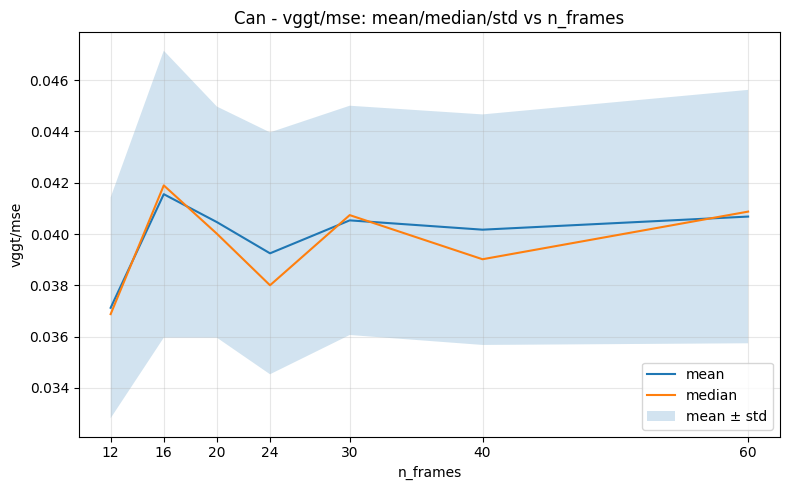

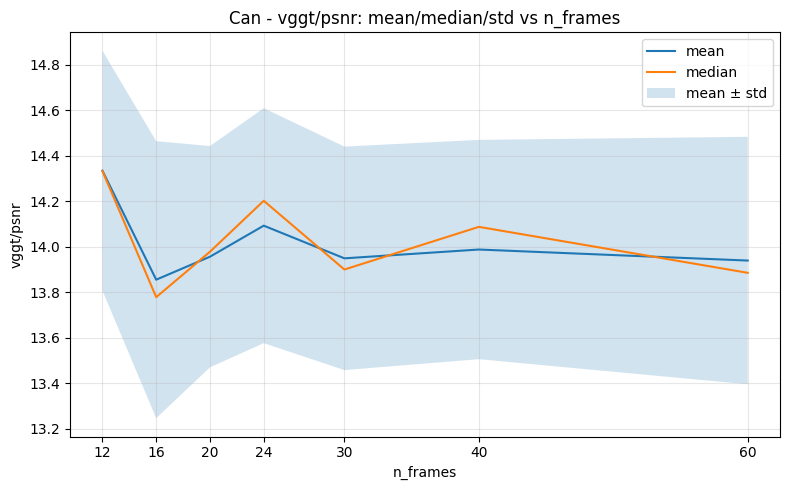

In [15]:
plot_mean_median_std_over_frames(
    stats_can_df,
    metrics=metrics,
    title_prefix="Can - ",
    clamp_lower=True
)

The average mean remains roughly the same of the frames for MSE and PSNR.

##### rendered Heatmaps
front und ca 210 (hinten links)

#### Florian

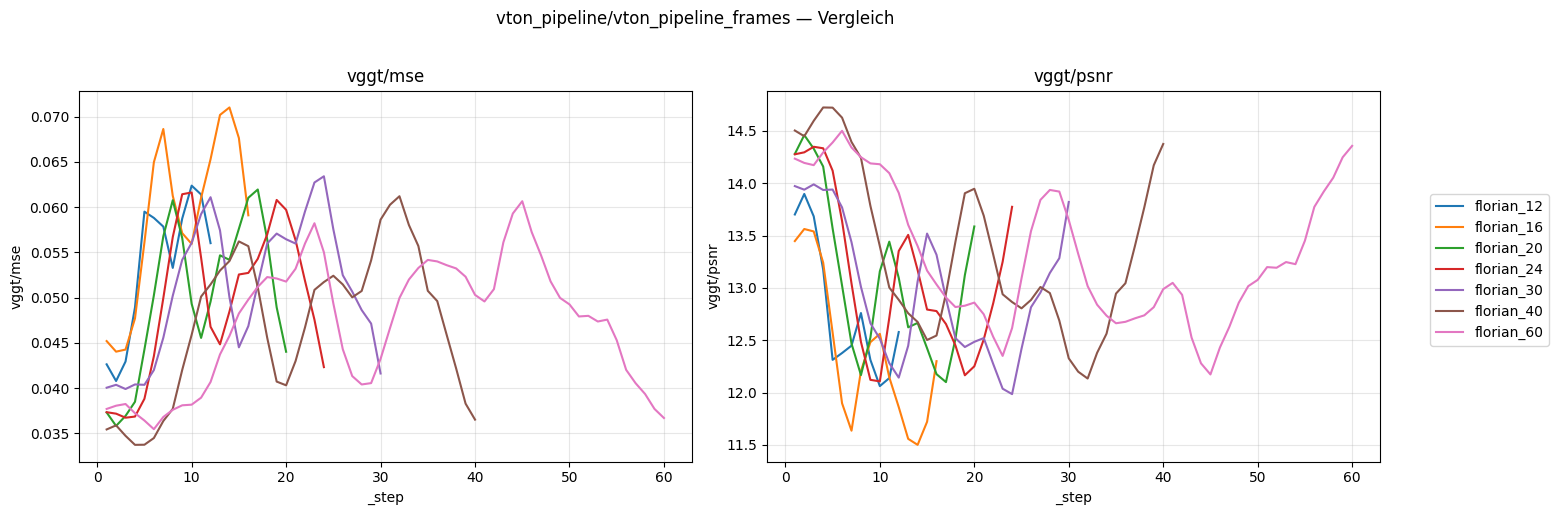

In [9]:
plot_two_metrics(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=metrics,
    xkey="_step",
    smooth_window=3
)

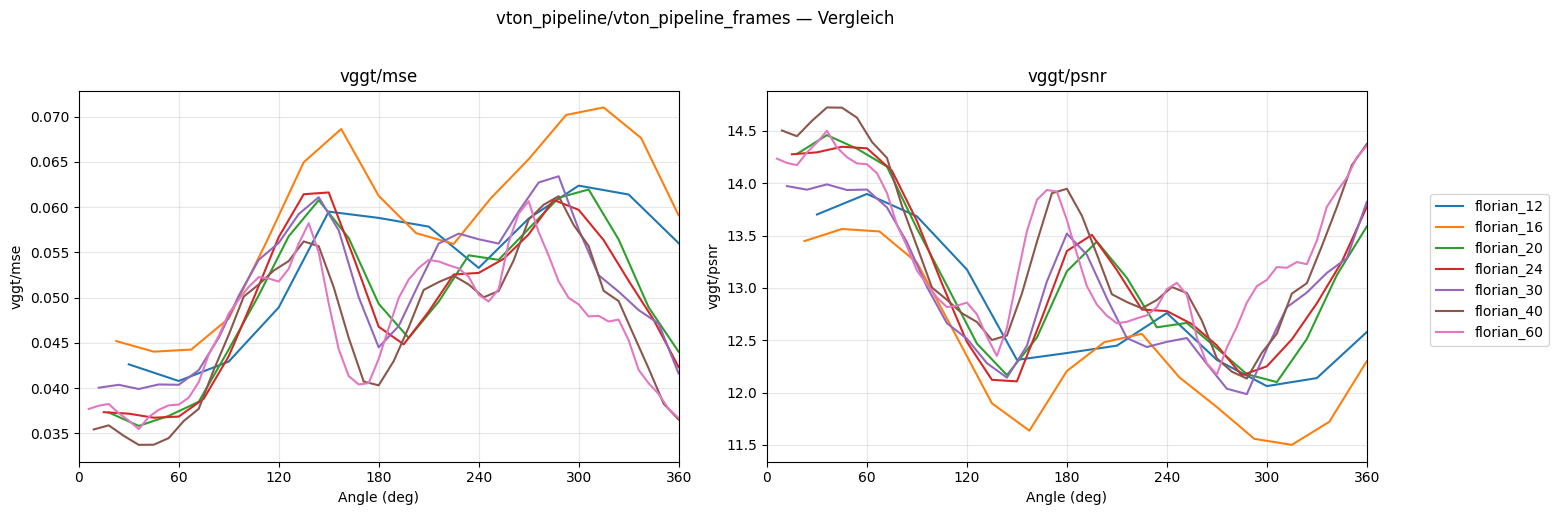

In [8]:
plot_two_metrics_with_x_360(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=metrics,
    xkey="_step",
    smoothing_window=3,
    include_360_endpoint=False
)

The dominant errors look viewpoint-driven (angle-dependent difficulty) and not primarily caused by “too few frames.” 

In [17]:
rows_f = []
for label in florian_labels:
    for metric in metrics:
        rows_f.append(metric_stats_for_label(label, metric))

stats_florian_df = pd.DataFrame(rows_f).sort_values(["metric", "n_frames"])
stats_florian_df

,label,n_frames,metric,mean,median,std,p05,p95,min,max,n_points
0,florian_12,12,vggt/mse,0.054131,0.055535,0.009863,0.040981,0.069544,0.038955,0.070694,12
2,florian_16,16,vggt/mse,0.059370,0.061391,0.010408,0.044266,0.073212,0.042869,0.077654,16
4,florian_20,20,vggt/mse,0.050198,0.051263,0.009691,0.037174,0.065480,0.034349,0.066863,20
6,florian_24,24,vggt/mse,0.049592,0.051692,0.009243,0.036096,0.063598,0.035849,0.064173,24
8,florian_30,30,vggt/mse,0.050938,0.052821,0.008364,0.039466,0.063805,0.036815,0.067910,30
10,florian_40,40,vggt/mse,0.046915,0.049174,0.008634,0.034531,0.061061,0.032427,0.063878,40
12,florian_60,60,vggt/mse,0.047017,0.047699,0.007304,0.035975,0.058071,0.034311,0.063126,60
1,florian_12,12,vggt/psnr,12.738615,12.555875,0.800014,11.577859,13.878556,11.506166,14.094393,12
3,florian_16,16,vggt/psnr,12.334229,12.118983,0.788907,11.356746,13.540053,11.098334,13.678556,16
5,florian_20,20,vggt/psnr,13.075931,12.902078,0.854009,11.838989,14.298286,11.748117,14.640856,20


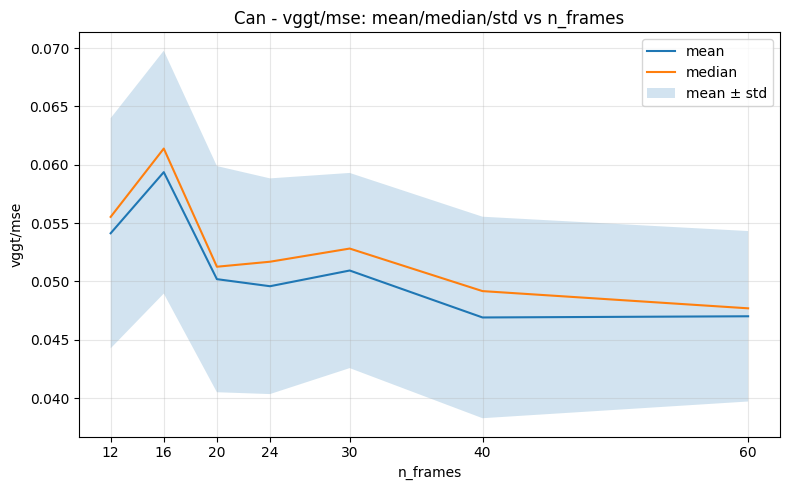

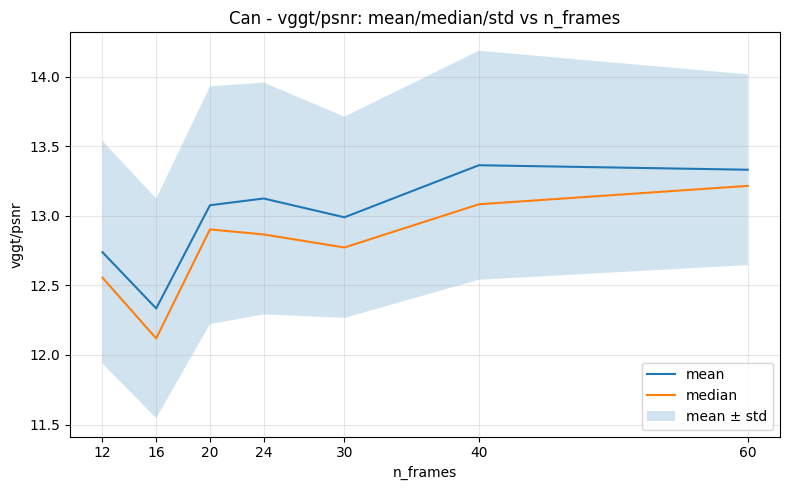

In [18]:
plot_mean_median_std_over_frames(
    stats_florian_df,
    metrics=metrics,
    title_prefix="Florian - ",
    clamp_lower=True
)

The variance for Florian is higher than for Can. The Performance from Can's Frames are better than Florian's Frames.

##### rendered Heatmaps

#### Comparison

In [10]:
rows = []
for label in can_labels + florian_labels:
    for metric in metrics:
        rows.append(metric_stats_for_label(label, metric))

stats_df = pd.DataFrame(rows).sort_values(["metric", "n_frames", "person"])

,label,person,n_frames,metric,mean,median,std,p05,p95,min,max,n_points
0,can_12,can,12,vggt/mse,0.037124,0.036877,0.004305,0.031020,0.043528,0.027069,0.045251,12
14,florian_12,florian,12,vggt/mse,0.054131,0.055535,0.009863,0.040981,0.069544,0.038955,0.070694,12
2,can_16,can,16,vggt/mse,0.041554,0.041895,0.005594,0.031357,0.049035,0.031002,0.051328,16
16,florian_16,florian,16,vggt/mse,0.059370,0.061391,0.010408,0.044266,0.073212,0.042869,0.077654,16
4,can_20,can,20,vggt/mse,0.040464,0.040011,0.004506,0.033865,0.047191,0.031555,0.048428,20
18,florian_20,florian,20,vggt/mse,0.050198,0.051263,0.009691,0.037174,0.065480,0.034349,0.066863,20
6,can_24,can,24,vggt/mse,0.039247,0.038002,0.004715,0.032549,0.046508,0.031517,0.049348,24
20,florian_24,florian,24,vggt/mse,0.049592,0.051692,0.009243,0.036096,0.063598,0.035849,0.064173,24
8,can_30,can,30,vggt/mse,0.040533,0.040737,0.004470,0.033704,0.047243,0.030037,0.049263,30
22,florian_30,florian,30,vggt/mse,0.050938,0.052821,0.008364,0.039466,0.063805,0.036815,0.067910,30


In [11]:
agg = (
    stats_df
    .groupby(["metric", "n_frames"], as_index=False)
    .agg(
        mean_mean=("mean", "mean"),
        mean_median=("median", "mean"),
        mean_p95=("p95", "mean"),
        mean_max=("max", "mean"),
    )
    .sort_values(["metric", "n_frames"])
)
agg

,metric,n_frames,mean_mean,mean_median,mean_p95,mean_max
0,vggt/mse,12,0.045627,0.046206,0.056536,0.057973
1,vggt/mse,16,0.050462,0.051643,0.061124,0.064491
2,vggt/mse,20,0.045331,0.045637,0.056335,0.057646
3,vggt/mse,24,0.044420,0.044847,0.055053,0.056761
4,vggt/mse,30,0.045736,0.046779,0.055524,0.058586
5,vggt/mse,40,0.043542,0.044096,0.054508,0.056627
6,vggt/mse,60,0.043849,0.044286,0.053367,0.057358
7,vggt/psnr,12,13.536513,13.444322,14.495815,14.884842
8,vggt/psnr,16,13.094801,12.948792,14.288426,14.382310
9,vggt/psnr,20,13.516147,13.440149,14.500682,14.825083


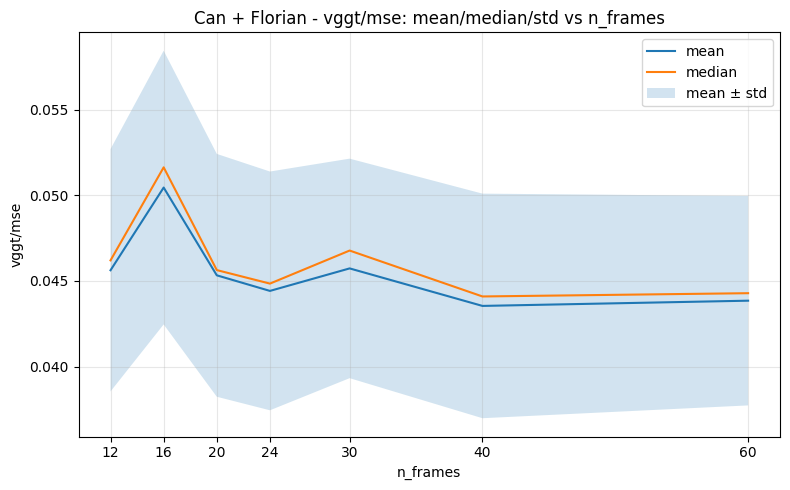

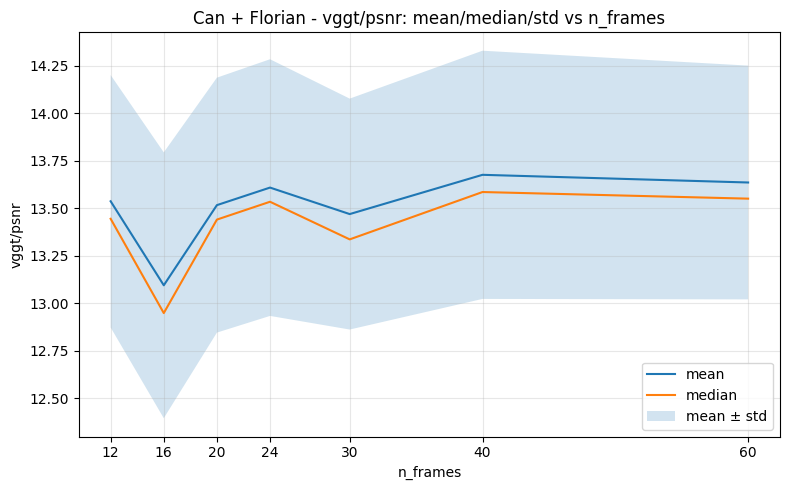

In [19]:
plot_mean_median_std_over_frames(
    stats_df,
    metrics=metrics,
    title_prefix="Can + Florian - ",
    clamp_lower=True
)

In terms of a reasonable trade-off between quality and performance, the 30 or 40 frames look like it could be a good choice for VGGT.

### QWEN

Not interesting for this experiment.

### GSPLAT

#### Can

##### Train

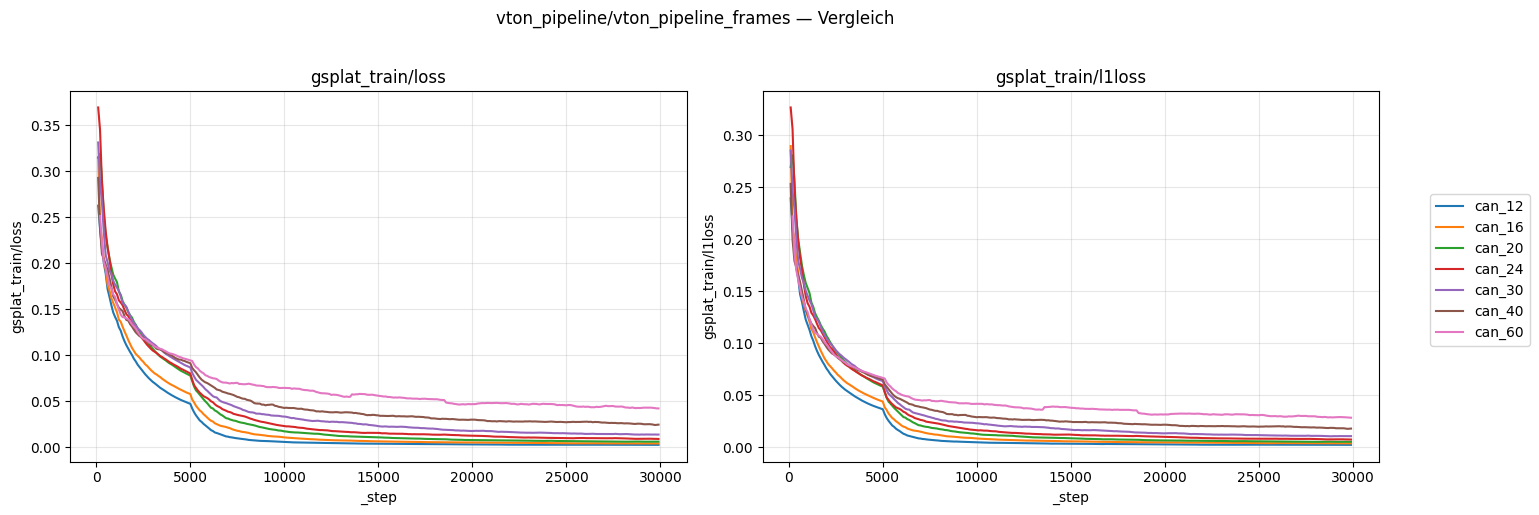

In [21]:
plot_two_metrics(
    labels=can_labels,
    run_paths=run_paths,
    metrics=["gsplat_train/loss", "gsplat_train/l1loss"],
    xkey=xkey,
    smooth_window=50,
)


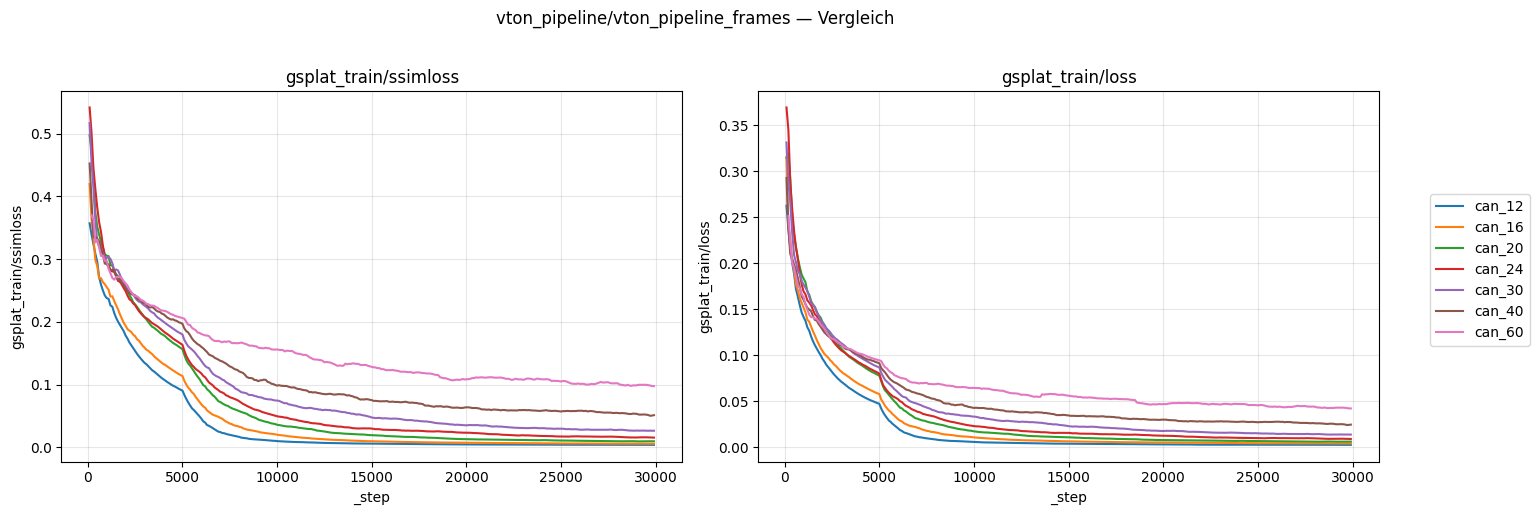

In [22]:
plot_two_metrics(
    labels=can_labels,
    run_paths=run_paths,
    metrics=["gsplat_train/ssimloss", "gsplat_train/num_GS"],
    xkey=xkey,
    smooth_window=50,
)

Die Train-Kurven (loss/l1loss/ssimloss) konvergieren ähnlich und kein Run wirkt “untertrainiert”. 

##### Val

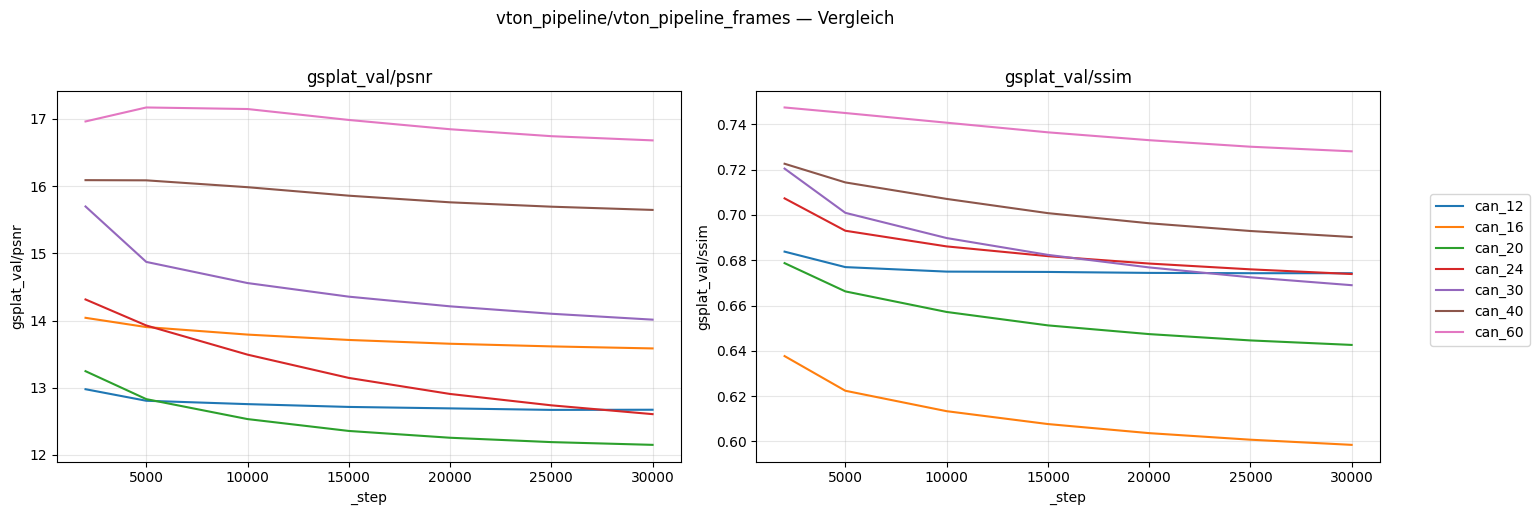

In [23]:
# %%
plot_two_metrics(
    labels=can_labels,
    run_paths=run_paths,
    metrics=["gsplat_val/psnr", "gsplat_val/ssim"],
    xkey="_step",
    smooth_window=10,
)


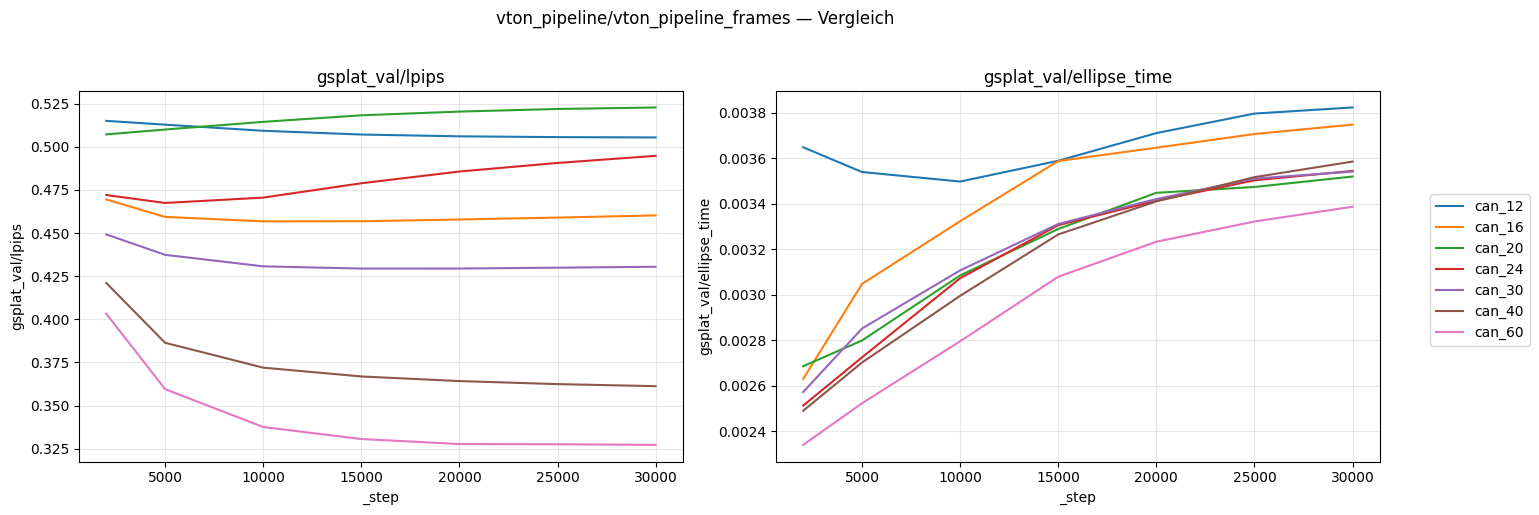

In [24]:
# %%
plot_two_metrics(
    labels=can_labels,
    run_paths=run_paths,
    metrics=["gsplat_val/lpips", "gsplat_val/ellipse_time"],
    xkey="_step",
    smooth_window=10,
)


#### Florian

##### Train

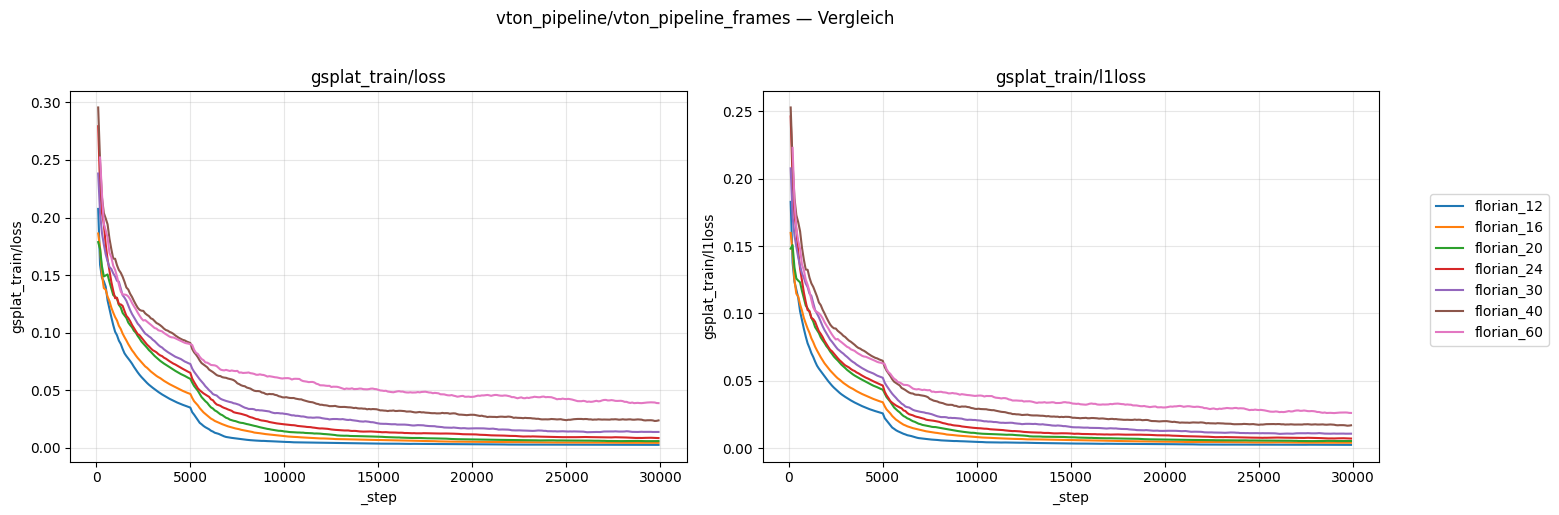

In [25]:
plot_two_metrics(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=["gsplat_train/loss", "gsplat_train/l1loss"],
    xkey=xkey,
    smooth_window=50,
)

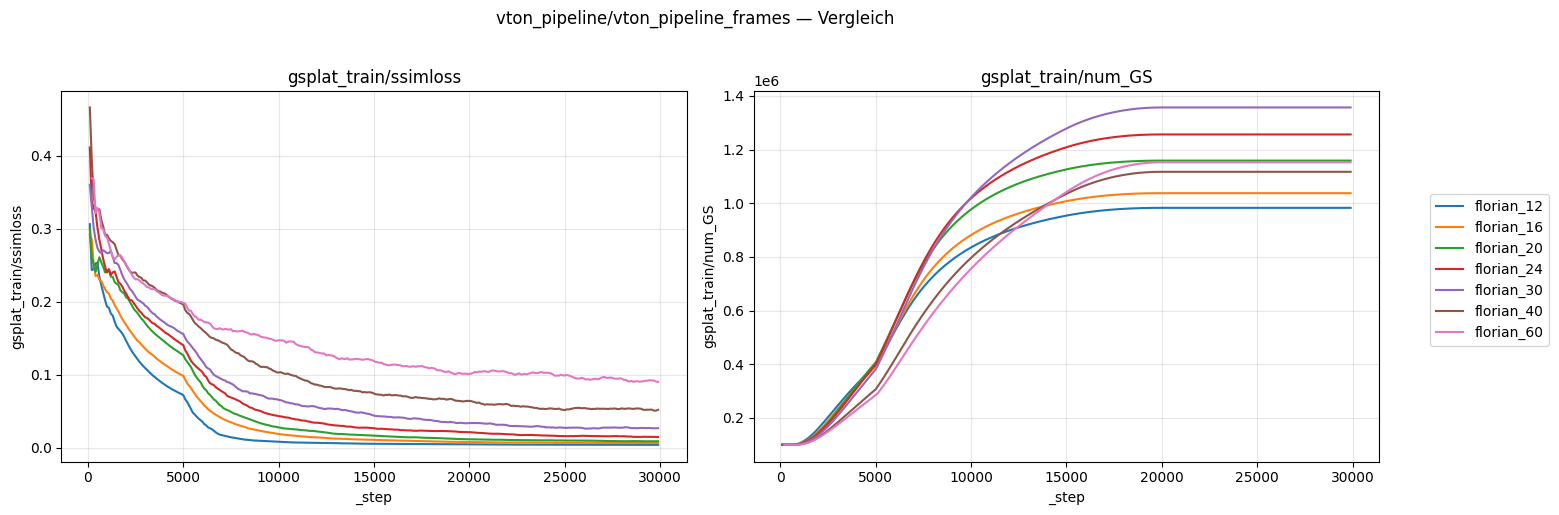

In [26]:
plot_two_metrics(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=["gsplat_train/ssimloss", "gsplat_train/num_GS"],
    xkey=xkey,
    smooth_window=50,
)

Die Train-Kurven (loss/l1loss/ssimloss) konvergieren ähnlich und kein Run wirkt “untertrainiert”. 

##### Val

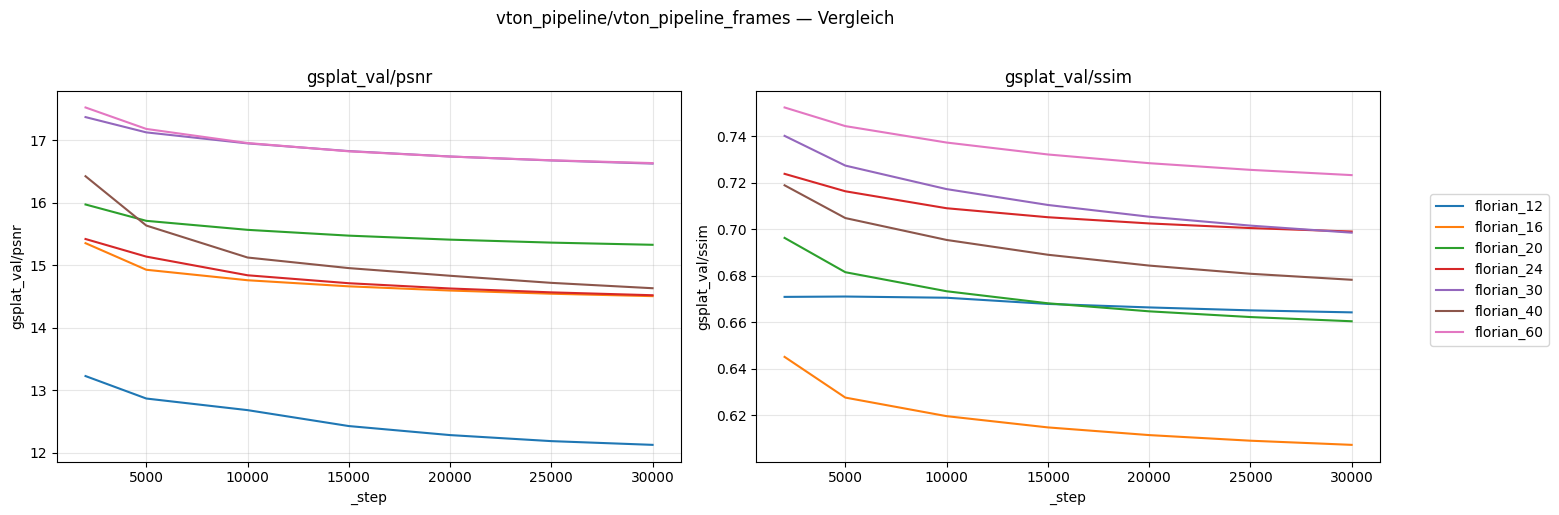

In [27]:
# %%
plot_two_metrics(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=["gsplat_val/psnr", "gsplat_val/ssim"],
    xkey="_step",
    smooth_window=10,
)

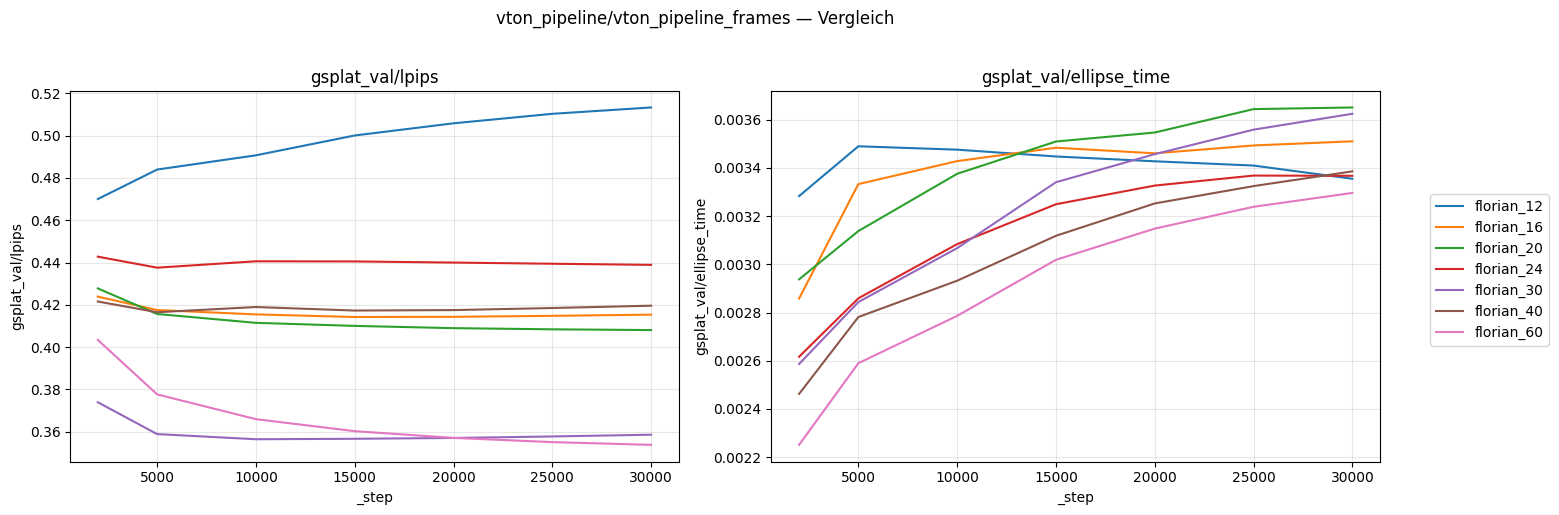

In [28]:
# %%
plot_two_metrics(
    labels=florian_labels,
    run_paths=run_paths,
    metrics=["gsplat_val/lpips", "gsplat_val/ellipse_time"],
    xkey="_step",
    smooth_window=10,
)

#### Comparison

In [32]:
# %%
def best_or_last(df, metric, mode="last"):
    """
    mode:
      - "last": letzter Wert
      - "max": bestes (max) für PSNR/SSIM
      - "min": bestes (min) für LPIPS/Loss
    """
    if df.empty:
        return np.nan, np.nan
    if mode == "last":
        r = df.iloc[-1]
        return float(r[metric]), float(r["_step"])
    if mode == "max":
        idx = df[metric].astype(float).idxmax()
        r = df.loc[idx]
        return float(r[metric]), float(r["_step"])
    if mode == "min":
        idx = df[metric].astype(float).idxmin()
        r = df.loc[idx]
        return float(r[metric]), float(r["_step"])
    raise ValueError(mode)


def summarize_gsplat_run(label):
    out = {"label": label, "n_frames": infer_n_frames(label), "person": "can" if "can_" in label else "florian"}
    # VAL quality
    for metric, mode in [("gsplat_val/psnr","max"), ("gsplat_val/ssim","max"), ("gsplat_val/lpips","min")]:
        df, _ = load_metric(run_paths[label], metric, xkey="_step")
        v_best, s_best = best_or_last(df, metric, mode=mode)
        v_last, s_last = best_or_last(df, metric, mode="last")
        out[f"{metric}_best"] = v_best
        out[f"{metric}_best_step"] = s_best
        out[f"{metric}_last"] = v_last
        out[f"{metric}_last_step"] = s_last

    # VAL efficiency & complexity (last is usually fine)
    for metric in ["gsplat_val/ellipse_time", "gsplat_val/num_GS"]:
        df, _ = load_metric(run_paths[label], metric, xkey="_step")
        v_last, _ = best_or_last(df, metric, mode="last")
        out[f"{metric}_last"] = v_last

    # TRAIN resources (last)
    for metric in ["gsplat_train/mem_gb", "gsplat_train/num_GS"]:
        df, _ = load_metric(run_paths[label], metric, xkey="_step")
        v_last, _ = best_or_last(df, metric, mode="last")
        out[f"{metric}_last"] = v_last

    return out

gsplat_summary = pd.DataFrame([summarize_gsplat_run(l) for l in all_labels]).sort_values(["person","n_frames"])
gsplat_summary


,label,n_frames,person,gsplat_val/psnr_best,gsplat_val/psnr_best_step,gsplat_val/psnr_last,gsplat_val/psnr_last_step,gsplat_val/ssim_best,gsplat_val/ssim_best_step,gsplat_val/ssim_last,gsplat_val/ssim_last_step,gsplat_val/lpips_best,gsplat_val/lpips_best_step,gsplat_val/lpips_last,gsplat_val/lpips_last_step,gsplat_val/ellipse_time_last,gsplat_val/num_GS_last,gsplat_train/mem_gb_last,gsplat_train/num_GS_last
0,can_12,12,can,12.977711,1999.0,12.686064,29999.0,0.683806,1999.0,0.674227,29999.0,0.500536,14999.0,0.504354,29999.0,0.003984,945145.0,1.441363,945145.0
1,can_16,16,can,14.039970,1999.0,13.402769,29999.0,0.637653,1999.0,0.584780,29999.0,0.449205,4999.0,0.467686,29999.0,0.003995,952220.0,1.451157,952220.0
2,can_20,20,can,13.245959,1999.0,11.904562,29999.0,0.678729,1999.0,0.630664,29999.0,0.507174,1999.0,0.528042,29999.0,0.003794,975389.0,1.492021,975389.0
3,can_24,24,can,14.313314,1999.0,11.820529,29999.0,0.707337,1999.0,0.661482,29999.0,0.462803,4999.0,0.519513,29999.0,0.003792,1093746.0,1.660169,1093746.0
4,can_30,30,can,15.696694,1999.0,13.486759,29999.0,0.720491,1999.0,0.648069,29999.0,0.417339,9999.0,0.433623,29999.0,0.003725,1103438.0,1.672657,1103438.0
5,can_40,40,can,16.088415,1999.0,15.357025,29999.0,0.722635,1999.0,0.674354,29999.0,0.343128,9999.0,0.354085,29999.0,0.003996,1317494.0,1.984405,1317494.0
6,can_60,60,can,17.377792,4999.0,16.304457,29999.0,0.747503,1999.0,0.715911,29999.0,0.293637,9999.0,0.325149,29999.0,0.003776,1306706.0,1.969648,1306706.0
7,florian_12,12,florian,13.229488,1999.0,11.772269,29999.0,0.671250,4999.0,0.659107,29999.0,0.470028,1999.0,0.531369,29999.0,0.003027,983070.0,1.497176,983070.0
8,florian_16,16,florian,15.354086,1999.0,14.274955,29999.0,0.645127,1999.0,0.596572,29999.0,0.410510,14999.0,0.418760,29999.0,0.003614,1037732.0,1.573133,1037732.0
9,florian_20,20,florian,15.972846,1999.0,15.119656,29999.0,0.696327,1999.0,0.649569,29999.0,0.403087,9999.0,0.405914,29999.0,0.003691,1159085.0,1.750355,1159085.0


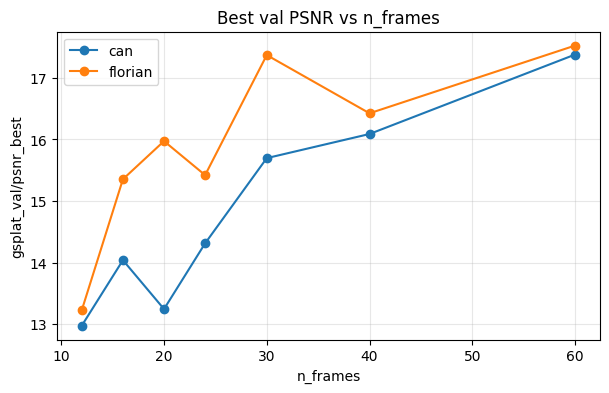

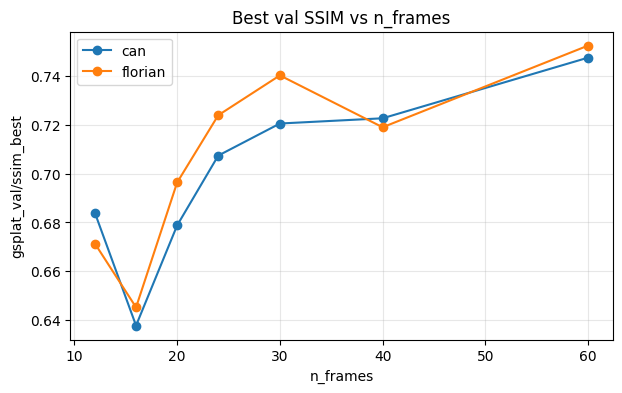

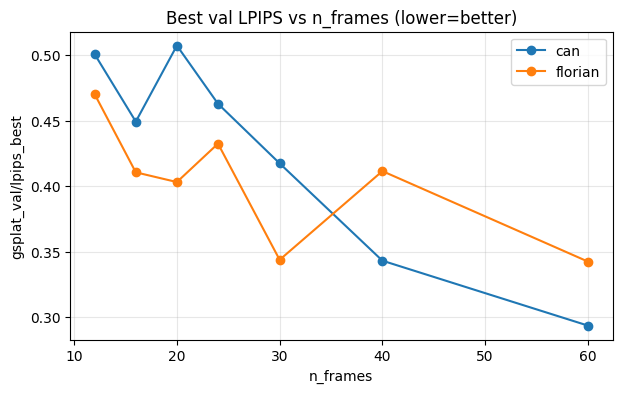

In [33]:
# %%
def plot_metric_vs_nframes(df, ycol, title):
    plt.figure(figsize=(7,4))
    for person in sorted(df["person"].unique()):
        d = df[df["person"]==person].sort_values("n_frames")
        plt.plot(d["n_frames"], d[ycol], marker="o", label=person)
    plt.xlabel("n_frames")
    plt.ylabel(ycol)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metric_vs_nframes(gsplat_summary, "gsplat_val/psnr_best", "Best val PSNR vs n_frames")
plot_metric_vs_nframes(gsplat_summary, "gsplat_val/ssim_best", "Best val SSIM vs n_frames")
plot_metric_vs_nframes(gsplat_summary, "gsplat_val/lpips_best", "Best val LPIPS vs n_frames (lower=better)")


In [34]:
# %%
# Kombiniert über Personen (vorsichtig interpretieren, da Personen unterschiedlich schwer sind)
comb = (gsplat_summary
        .groupby("n_frames", as_index=False)
        .agg(
            psnr_best_mean=("gsplat_val/psnr_best","mean"),
            ssim_best_mean=("gsplat_val/ssim_best","mean"),
            lpips_best_mean=("gsplat_val/lpips_best","mean"),
            numGS_mean=("gsplat_train/num_GS_last","mean"),
            mem_mean=("gsplat_train/mem_gb_last","mean"),
            ellipse_mean=("gsplat_val/ellipse_time_last","mean"),
        )
        .sort_values("n_frames"))
comb


,n_frames,psnr_best_mean,ssim_best_mean,lpips_best_mean,numGS_mean,mem_mean,ellipse_mean
0,12,13.103600,0.677528,0.485282,964107.5,1.469269,0.003505
1,16,14.697028,0.641390,0.429858,994976.0,1.512145,0.003804
2,20,14.609403,0.687528,0.455130,1067237.0,1.621188,0.003743
3,24,14.867052,0.715609,0.447589,1175185.0,1.778421,0.003576
4,30,16.533298,0.730357,0.380567,1230285.5,1.855796,0.003872
5,40,16.256437,0.720795,0.377282,1217412.5,1.836029,0.003874
6,60,17.450879,0.749973,0.318049,1229830.5,1.857791,0.003709


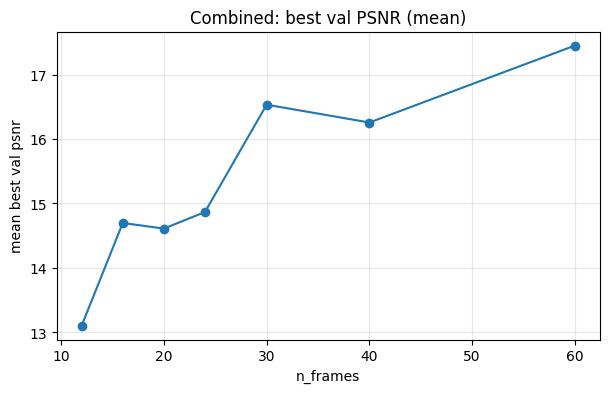

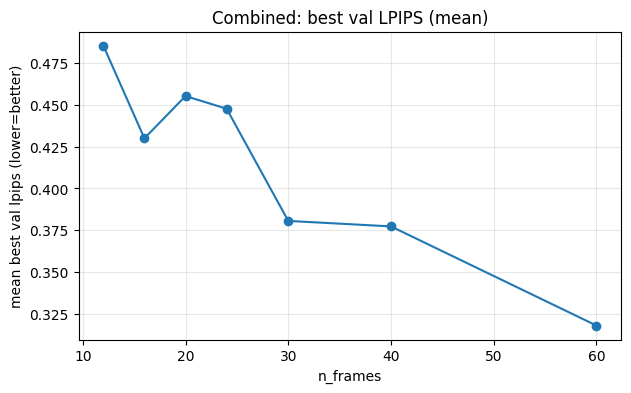

In [35]:
# %%
plt.figure(figsize=(7,4))
plt.plot(comb["n_frames"], comb["psnr_best_mean"], marker="o")
plt.xlabel("n_frames"); plt.ylabel("mean best val psnr"); plt.title("Combined: best val PSNR (mean)"); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(comb["n_frames"], comb["lpips_best_mean"], marker="o")
plt.xlabel("n_frames"); plt.ylabel("mean best val lpips (lower=better)"); plt.title("Combined: best val LPIPS (mean)"); plt.grid(True, alpha=0.3)
plt.show()


## Conclusion
Based on VGGT + GSPLAT results:

nf16: consistently weak (VGGT and gsplat-Val tend to be worse) → exclude.

n_frames ≥ 20: significant leap in quality (VGGT aggregations clearly show this, gsplat-Val curves are more stable).

Plateau from ~40: (VGGT combined clear; gsplat-Val also shows that additional frames do not necessarily improve all metrics further).

nf60: often higher model complexity (num_GS/mem) without a clear “always better” gain → only if a Val metric gains significantly and costs are acceptable.

Conclusion:
nf30 or nf40 as a good compromise between quality and performance/cost. In GSPLAT, nf30 often proves to be the best choice (similar quality to nf40, but lower resource usage).

SO we take 30 frames for the Vton Pipeline as default going forward.